# Prepare UNIQUE input data for CLint endpoints

---

Preparing CLint input datasets to run UNIQUE Pipeline includes the following steps:
- Importing the preprocessed CLint dataset.
- Integrating predictions from Chemprop and corresponding uncertainty estimates (ensemble variance).
- Adding and scaling GNN latent fingerprints.

In [1]:
import os 
import numpy as np 
import pandas as pd
pd.set_option('display.max_columns', None)

## Load CLint data

In [2]:
df = pd.read_csv('data/CLint_dataset_with_splits.csv', index_col=0)
df.head()

,Id,Structure,mol,rLM LogCLint,hLM LogCLint,Subset,split
0,Mol1,CNc1cc(Nc2cccn(-c3ccccn3)c2=O)nn2c(C(=O)N[C@@H...,<rdkit.Chem.rdchem.Mol object at 0x76625c680c10>,1.392169,0.675687,Training,train
1,Mol6,CC#CC(=O)N[C@H]1CCCN(c2c(F)cc(C(N)=O)c3[nH]c(C...,<rdkit.Chem.rdchem.Mol object at 0x76625c681310>,2.376374,1.397349,Training,train
2,Mol8,COc1ccc(Cl)cc1C(=O)NCCc1ccc(S(=O)(=O)NC(=O)NC2...,<rdkit.Chem.rdchem.Mol object at 0x76625c6813f0>,2.728062,1.458063,Training,train
3,Mol9,C=CC(=O)N1CCC[C@@H](n2nc(-c3ccc(Oc4ccccc4)cc3)...,<rdkit.Chem.rdchem.Mol object at 0x76625c681460>,3.243300,2.756500,Training,train
4,Mol10,CC(C)NC(=O)COc1cccc(-c2nc(Nc3ccc4[nH]ncc4c3)c3...,<rdkit.Chem.rdchem.Mol object at 0x76625c6814d0>,3.192741,1.630824,Training,train


In [3]:
df['which_set'] = df['Subset'].copy()
df['which_set'] = df['which_set'].replace({'Training':'TRAIN', 'Calibration':'CALIBRATION', 'Validation':'TEST'})
df['which_set'].value_counts()

which_set
TRAIN          1546
CALIBRATION     926
TEST            617
Name: count, dtype: int64

Select columns

In [4]:
df = df[['Id','Structure','rLM LogCLint','hLM LogCLint','which_set']]
df.head()

,Id,Structure,rLM LogCLint,hLM LogCLint,which_set
0,Mol1,CNc1cc(Nc2cccn(-c3ccccn3)c2=O)nn2c(C(=O)N[C@@H...,1.392169,0.675687,TRAIN
1,Mol6,CC#CC(=O)N[C@H]1CCCN(c2c(F)cc(C(N)=O)c3[nH]c(C...,2.376374,1.397349,TRAIN
2,Mol8,COc1ccc(Cl)cc1C(=O)NCCc1ccc(S(=O)(=O)NC(=O)NC2...,2.728062,1.458063,TRAIN
3,Mol9,C=CC(=O)N1CCC[C@@H](n2nc(-c3ccc(Oc4ccccc4)cc3)...,3.243300,2.756500,TRAIN
4,Mol10,CC(C)NC(=O)COc1cccc(-c2nc(Nc3ccc4[nH]ncc4c3)c3...,3.192741,1.630824,TRAIN


## Read model predictions

In [5]:
df_preds = pd.read_csv('CLint_model/predictions.csv')
df_preds.head()

,Unnamed: 0,Id,Structure,mol,rLM LogCLint,hLM LogCLint,Subset,split,rLM LogCLint_unc,hLM LogCLint_unc
0,0,Mol1,CNc1cc(Nc2cccn(-c3ccccn3)c2=O)nn2c(C(=O)N[C@@H...,<rdkit.Chem.rdchem.Mol object at 0x76625c680c10>,1.390602,0.826801,Training,train,0.004089,0.002332
1,1,Mol6,CC#CC(=O)N[C@H]1CCCN(c2c(F)cc(C(N)=O)c3[nH]c(C...,<rdkit.Chem.rdchem.Mol object at 0x76625c681310>,2.626149,1.717698,Training,train,0.002975,0.003191
2,2,Mol8,COc1ccc(Cl)cc1C(=O)NCCc1ccc(S(=O)(=O)NC(=O)NC2...,<rdkit.Chem.rdchem.Mol object at 0x76625c6813f0>,2.490598,1.686410,Training,train,0.005649,0.004861
3,3,Mol9,C=CC(=O)N1CCC[C@@H](n2nc(-c3ccc(Oc4ccccc4)cc3)...,<rdkit.Chem.rdchem.Mol object at 0x76625c681460>,2.878103,1.868621,Training,train,0.006237,0.004062
4,4,Mol10,CC(C)NC(=O)COc1cccc(-c2nc(Nc3ccc4[nH]ncc4c3)c3...,<rdkit.Chem.rdchem.Mol object at 0x76625c6814d0>,2.898273,1.916554,Training,train,0.004985,0.004834


In [6]:
all([df.Id.iloc[x] == df_preds.Id.iloc[x] for x in range(df.shape[0])])

True

Rename columns

In [7]:
df_preds = df_preds.rename(columns={"rLM LogCLint": "predicted rLM LogCLint", "rLM LogCLint_unc": "variance rLM LogCLint",
                                    "hLM LogCLint": "predicted hLM LogCLint", "hLM LogCLint_unc": "variance hLM LogCLint"})

Select columns

In [8]:
df_preds = df_preds[['Id','predicted rLM LogCLint', 'predicted hLM LogCLint','variance rLM LogCLint','variance hLM LogCLint']]
df_preds.head()

,Id,predicted rLM LogCLint,predicted hLM LogCLint,variance rLM LogCLint,variance hLM LogCLint
0,Mol1,1.390602,0.826801,0.004089,0.002332
1,Mol6,2.626149,1.717698,0.002975,0.003191
2,Mol8,2.490598,1.686410,0.005649,0.004861
3,Mol9,2.878103,1.868621,0.006237,0.004062
4,Mol10,2.898273,1.916554,0.004985,0.004834


Merge predictions data

In [9]:
print(df.shape)
print(df_preds.shape)
df = df.merge(df_preds, on=['Id'])
print(df.shape)
df.head()

(3089, 5)
(3089, 5)
(3089, 9)


,Id,Structure,rLM LogCLint,hLM LogCLint,which_set,predicted rLM LogCLint,predicted hLM LogCLint,variance rLM LogCLint,variance hLM LogCLint
0,Mol1,CNc1cc(Nc2cccn(-c3ccccn3)c2=O)nn2c(C(=O)N[C@@H...,1.392169,0.675687,TRAIN,1.390602,0.826801,0.004089,0.002332
1,Mol6,CC#CC(=O)N[C@H]1CCCN(c2c(F)cc(C(N)=O)c3[nH]c(C...,2.376374,1.397349,TRAIN,2.626149,1.717698,0.002975,0.003191
2,Mol8,COc1ccc(Cl)cc1C(=O)NCCc1ccc(S(=O)(=O)NC(=O)NC2...,2.728062,1.458063,TRAIN,2.490598,1.686410,0.005649,0.004861
3,Mol9,C=CC(=O)N1CCC[C@@H](n2nc(-c3ccc(Oc4ccccc4)cc3)...,3.243300,2.756500,TRAIN,2.878103,1.868621,0.006237,0.004062
4,Mol10,CC(C)NC(=O)COc1cccc(-c2nc(Nc3ccc4[nH]ncc4c3)c3...,3.192741,1.630824,TRAIN,2.898273,1.916554,0.004985,0.004834


## Read GNN latent representations

In [10]:
df_latent = pd.read_csv('CLint_model/latent_fps_0.csv')
df_latent.head()

,fp_0,fp_1,fp_2,fp_3,fp_4,fp_5,fp_6,fp_7,fp_8,fp_9,fp_10,fp_11,fp_12,fp_13,fp_14,fp_15,fp_16,fp_17,fp_18,fp_19,fp_20,fp_21,fp_22,fp_23,fp_24,fp_25,fp_26,fp_27,fp_28,fp_29,fp_30,fp_31,fp_32,fp_33,fp_34,fp_35,fp_36,fp_37,fp_38,fp_39,fp_40,fp_41,fp_42,fp_43,fp_44,fp_45,fp_46,fp_47,fp_48,fp_49,fp_50,fp_51,fp_52,fp_53,fp_54,fp_55,fp_56,fp_57,fp_58,fp_59,fp_60,fp_61,fp_62,fp_63,fp_64,fp_65,fp_66,fp_67,fp_68,fp_69,fp_70,fp_71,fp_72,fp_73,fp_74,fp_75,fp_76,fp_77,fp_78,fp_79,fp_80,fp_81,fp_82,fp_83,fp_84,fp_85,fp_86,fp_87,fp_88,fp_89,fp_90,fp_91,fp_92,fp_93,fp_94,fp_95,fp_96,fp_97,fp_98,fp_99,fp_100,fp_101,fp_102,fp_103,fp_104,fp_105,fp_106,fp_107,fp_108,fp_109,fp_110,fp_111,fp_112,fp_113,fp_114,fp_115,fp_116,fp_117,fp_118,fp_119,fp_120,fp_121,fp_122,fp_123,fp_124,fp_125,fp_126,fp_127,fp_128,fp_129,fp_130,fp_131,fp_132,fp_133,fp_134,fp_135,fp_136,fp_137,fp_138,fp_139,fp_140,fp_141,fp_142,fp_143,fp_144,fp_145,fp_146,fp_147,fp_148,fp_149,fp_150,fp_151,fp_152,fp_153,fp_154,fp_155,fp_156,fp_157,fp_158,fp_159,fp_160,fp_161,fp_162,fp_163,fp_164,fp_165,fp_166,fp_167,fp_168,fp_169,fp_170,fp_171,fp_172,fp_173,fp_174,fp_175,fp_176,fp_177,fp_178,fp_179,fp_180,fp_181,fp_182,fp_183,fp_184,fp_185,fp_186,fp_187,fp_188,fp_189,fp_190,fp_191,fp_192,fp_193,fp_194,fp_195,fp_196,fp_197,fp_198,fp_199,fp_200,fp_201,fp_202,fp_203,fp_204,fp_205,fp_206,fp_207,fp_208,fp_209,fp_210,fp_211,fp_212,fp_213,fp_214,fp_215,fp_216,fp_217,fp_218,fp_219,fp_220,fp_221,fp_222,fp_223,fp_224,fp_225,fp_226,fp_227,fp_228,fp_229,fp_230,fp_231,fp_232,fp_233,fp_234,fp_235,fp_236,fp_237,fp_238,fp_239,fp_240,fp_241,fp_242,fp_243,fp_244,fp_245,fp_246,fp_247,fp_248,fp_249,fp_250,fp_251,fp_252,fp_253,fp_254,fp_255,fp_256,fp_257,fp_258,fp_259,fp_260,fp_261,fp_262,fp_263,fp_264,fp_265,fp_266,fp_267,fp_268,fp_269,fp_270,fp_271,fp_272,fp_273,fp_274,fp_275,fp_276,fp_277,fp_278,fp_279,fp_280,fp_281,fp_282,fp_283,fp_284,fp_285,fp_286,fp_287,fp_288,fp_289,fp_290,fp_291,fp_292,fp_293,fp_294,fp_295,fp_296,fp_297,fp_298,fp_299
0,0.102347,0.054541,0.032198,0.021910,0.080763,0.054561,0.054558,0.076734,0.021058,0.051388,0.078008,0.016625,0.042656,0.064288,0.080322,0.011311,0.076945,0.048391,0.054067,0.085729,0.046380,0.047139,0.019532,0.019619,0.119058,0.022409,0.085173,0.031565,0.051127,0.051672,0.026186,0.015438,0.005633,0.048692,0.039253,0.060406,0.058025,0.010882,0.068090,0.015860,0.069062,0.000000,0.076146,0.061541,0.028958,0.047042,0.031075,0.010595,0.092155,0.039163,0.058588,0.003852,0.018171,0.038357,0.071770,0.017127,0.079550,0.060592,0.000000,0.000000,0.036933,0.060277,0.049305,0.038145,0.083940,0.0,0.003250,0.0,0.027118,0.056629,0.075868,0.011965,0.041859,0.010377,0.046608,0.042506,0.047884,0.018655,0.106667,0.035859,0.106805,0.025074,0.056745,0.000693,0.003708,0.098430,0.101758,0.0,0.011152,0.090362,0.0,0.062805,0.014348,0.019577,0.049730,0.022948,0.125368,0.101927,0.061917,0.027272,0.082152,0.055059,0.028944,0.046703,0.014997,0.040303,0.014353,0.009739,0.032570,0.025489,0.046694,0.011549,0.041857,0.002865,0.000000,0.026797,0.017145,0.064090,0.0,0.060989,0.094570,0.016325,0.029194,0.022399,0.0,0.067501,0.061959,0.0,0.029182,0.067182,0.008651,0.027078,0.098394,0.016457,0.005934,0.001258,0.030848,0.025616,0.002892,0.071214,0.033300,0.040931,0.023619,0.0,0.004965,0.088929,0.0,0.076484,0.020897,0.081882,0.048407,0.012411,0.089589,0.019037,0.027291,0.053189,0.015330,0.029546,0.072273,0.115715,0.064427,0.071009,0.044495,0.058469,0.0,0.086507,0.007881,0.017760,0.019925,0.052018,0.052330,0.021329,0.019409,0.012720,0.051125,0.042717,0.042608,0.009204,0.076010,0.148097,0.029730,0.053642,0.025328,0.026530,0.059228,0.017588,0.006959,0.029966,0.029815,0.122906,0.071648,0.046879,0.0,0.0,0.066169,0.055076,0.004837,0.039374,0.001438,0.056531,0.0,0.035248,0.0,0.006546,0.023235,0.012112,0.015332,0.013690,0.0,0.029187,0.054121,0.012464,0.008457,0.073394,0.048189,0.099142,0.029388,0.076162,0.072855,0.019686,0.061909,0.012053,0.014900,0.102035,0.110489,0.036725,0.009172,0.021140,0.092959,0.077969,0.076917,0.0

Add SMILES data

In [11]:
original_data = pd.read_csv('data/CLint_dataset_with_splits.csv', index_col=0)
smiles = original_data['Structure']
smiles

0       CNc1cc(Nc2cccn(-c3ccccn3)c2=O)nn2c(C(=O)N[C@@H...
1       CC#CC(=O)N[C@H]1CCCN(c2c(F)cc(C(N)=O)c3[nH]c(C...
2       COc1ccc(Cl)cc1C(=O)NCCc1ccc(S(=O)(=O)NC(=O)NC2...
3       C=CC(=O)N1CCC[C@@H](n2nc(-c3ccc(Oc4ccccc4)cc3)...
4       CC(C)NC(=O)COc1cccc(-c2nc(Nc3ccc4[nH]ncc4c3)c3...
                              ...                        
3084            O=C(Nc1ccc(CN2CCCCC2)cc1)c1ccnc2[nH]cnc12
3085       NC(=O)c1cnc(N2CCc3[nH]nc(C(F)(F)F)c3C2)c(Cl)c1
3086             CC1CC(N)CCN1C(=O)c1cc(N2CCNC2=O)c(F)cc1F
3087                CCN1CCOC(C(=O)N2CCC(c3cn[nH]c3)CC2)C1
3088           CCCCCCCCc1ccc(CC[C@](N)(CO)COP(=O)(O)O)cc1
Name: Structure, Length: 3089, dtype: object

In [12]:
print(df_latent.shape)
print(smiles.shape)
df_latent = pd.concat([smiles, df_latent], axis=1)
print(df_latent.shape)
df_latent.head()

(3089, 300)
(3089,)
(3089, 301)


,Structure,fp_0,fp_1,fp_2,fp_3,fp_4,fp_5,fp_6,fp_7,fp_8,fp_9,fp_10,fp_11,fp_12,fp_13,fp_14,fp_15,fp_16,fp_17,fp_18,fp_19,fp_20,fp_21,fp_22,fp_23,fp_24,fp_25,fp_26,fp_27,fp_28,fp_29,fp_30,fp_31,fp_32,fp_33,fp_34,fp_35,fp_36,fp_37,fp_38,fp_39,fp_40,fp_41,fp_42,fp_43,fp_44,fp_45,fp_46,fp_47,fp_48,fp_49,fp_50,fp_51,fp_52,fp_53,fp_54,fp_55,fp_56,fp_57,fp_58,fp_59,fp_60,fp_61,fp_62,fp_63,fp_64,fp_65,fp_66,fp_67,fp_68,fp_69,fp_70,fp_71,fp_72,fp_73,fp_74,fp_75,fp_76,fp_77,fp_78,fp_79,fp_80,fp_81,fp_82,fp_83,fp_84,fp_85,fp_86,fp_87,fp_88,fp_89,fp_90,fp_91,fp_92,fp_93,fp_94,fp_95,fp_96,fp_97,fp_98,fp_99,fp_100,fp_101,fp_102,fp_103,fp_104,fp_105,fp_106,fp_107,fp_108,fp_109,fp_110,fp_111,fp_112,fp_113,fp_114,fp_115,fp_116,fp_117,fp_118,fp_119,fp_120,fp_121,fp_122,fp_123,fp_124,fp_125,fp_126,fp_127,fp_128,fp_129,fp_130,fp_131,fp_132,fp_133,fp_134,fp_135,fp_136,fp_137,fp_138,fp_139,fp_140,fp_141,fp_142,fp_143,fp_144,fp_145,fp_146,fp_147,fp_148,fp_149,fp_150,fp_151,fp_152,fp_153,fp_154,fp_155,fp_156,fp_157,fp_158,fp_159,fp_160,fp_161,fp_162,fp_163,fp_164,fp_165,fp_166,fp_167,fp_168,fp_169,fp_170,fp_171,fp_172,fp_173,fp_174,fp_175,fp_176,fp_177,fp_178,fp_179,fp_180,fp_181,fp_182,fp_183,fp_184,fp_185,fp_186,fp_187,fp_188,fp_189,fp_190,fp_191,fp_192,fp_193,fp_194,fp_195,fp_196,fp_197,fp_198,fp_199,fp_200,fp_201,fp_202,fp_203,fp_204,fp_205,fp_206,fp_207,fp_208,fp_209,fp_210,fp_211,fp_212,fp_213,fp_214,fp_215,fp_216,fp_217,fp_218,fp_219,fp_220,fp_221,fp_222,fp_223,fp_224,fp_225,fp_226,fp_227,fp_228,fp_229,fp_230,fp_231,fp_232,fp_233,fp_234,fp_235,fp_236,fp_237,fp_238,fp_239,fp_240,fp_241,fp_242,fp_243,fp_244,fp_245,fp_246,fp_247,fp_248,fp_249,fp_250,fp_251,fp_252,fp_253,fp_254,fp_255,fp_256,fp_257,fp_258,fp_259,fp_260,fp_261,fp_262,fp_263,fp_264,fp_265,fp_266,fp_267,fp_268,fp_269,fp_270,fp_271,fp_272,fp_273,fp_274,fp_275,fp_276,fp_277,fp_278,fp_279,fp_280,fp_281,fp_282,fp_283,fp_284,fp_285,fp_286,fp_287,fp_288,fp_289,fp_290,fp_291,fp_292,fp_293,fp_294,fp_295,fp_296,fp_297,fp_298,fp_299
0,CNc1cc(Nc2cccn(-c3ccccn3)c2=O)nn2c(C(=O)N[C@@H...,0.102347,0.054541,0.032198,0.021910,0.080763,0.054561,0.054558,0.076734,0.021058,0.051388,0.078008,0.016625,0.042656,0.064288,0.080322,0.011311,0.076945,0.048391,0.054067,0.085729,0.046380,0.047139,0.019532,0.019619,0.119058,0.022409,0.085173,0.031565,0.051127,0.051672,0.026186,0.015438,0.005633,0.048692,0.039253,0.060406,0.058025,0.010882,0.068090,0.015860,0.069062,0.000000,0.076146,0.061541,0.028958,0.047042,0.031075,0.010595,0.092155,0.039163,0.058588,0.003852,0.018171,0.038357,0.071770,0.017127,0.079550,0.060592,0.000000,0.000000,0.036933,0.060277,0.049305,0.038145,0.083940,0.0,0.003250,0.0,0.027118,0.056629,0.075868,0.011965,0.041859,0.010377,0.046608,0.042506,0.047884,0.018655,0.106667,0.035859,0.106805,0.025074,0.056745,0.000693,0.003708,0.098430,0.101758,0.0,0.011152,0.090362,0.0,0.062805,0.014348,0.019577,0.049730,0.022948,0.125368,0.101927,0.061917,0.027272,0.082152,0.055059,0.028944,0.046703,0.014997,0.040303,0.014353,0.009739,0.032570,0.025489,0.046694,0.011549,0.041857,0.002865,0.000000,0.026797,0.017145,0.064090,0.0,0.060989,0.094570,0.016325,0.029194,0.022399,0.0,0.067501,0.061959,0.0,0.029182,0.067182,0.008651,0.027078,0.098394,0.016457,0.005934,0.001258,0.030848,0.025616,0.002892,0.071214,0.033300,0.040931,0.023619,0.0,0.004965,0.088929,0.0,0.076484,0.020897,0.081882,0.048407,0.012411,0.089589,0.019037,0.027291,0.053189,0.015330,0.029546,0.072273,0.115715,0.064427,0.071009,0.044495,0.058469,0.0,0.086507,0.007881,0.017760,0.019925,0.052018,0.052330,0.021329,0.019409,0.012720,0.051125,0.042717,0.042608,0.009204,0.076010,0.148097,0.029730,0.053642,0.025328,0.026530,0.059228,0.017588,0.006959,0.029966,0.029815,0.122906,0.071648,0.046879,0.0,0.0,0.066169,0.055076,0.004837,0.039374,0.001438,0.056531,0.0,0.035248,0.0,0.006546,0.023235,0.012112,0.015332,0.013690,0.0,0.029187,0.054121,0.012464,0.008457,0.073394,0.048189,0.099142,0.029388,0.076162,0.072855,0.019686,0.061909,0.012053,0.014900,0.102035,0.1104

Inspect feature distributions and outlier identification

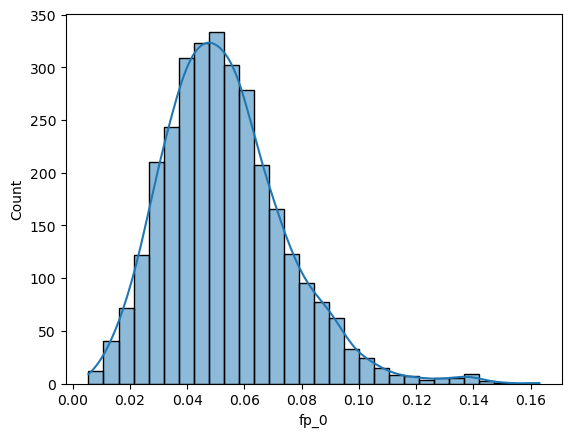

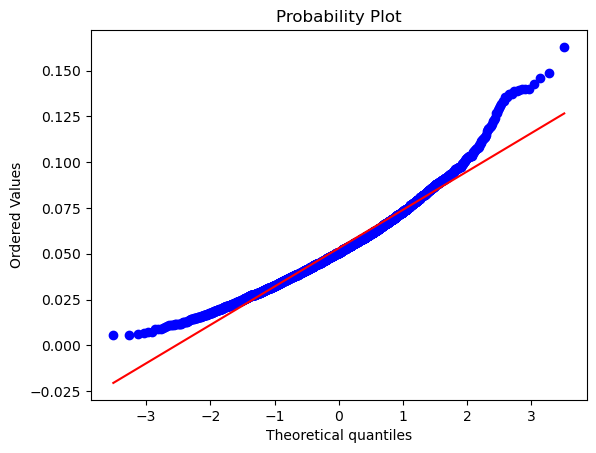

In [13]:
import matplotlib.pyplot as plt
import scipy.stats as stats
import seaborn as sns

# inspect the first latent feature
feature = df_latent['fp_0']
# histogram
sns.histplot(feature, kde=True, bins=30)
plt.show()
# Q-Q plot
stats.probplot(feature, dist="norm", plot=plt)
plt.show()

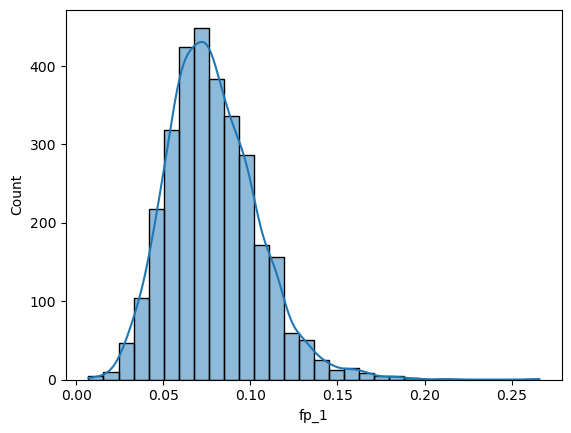

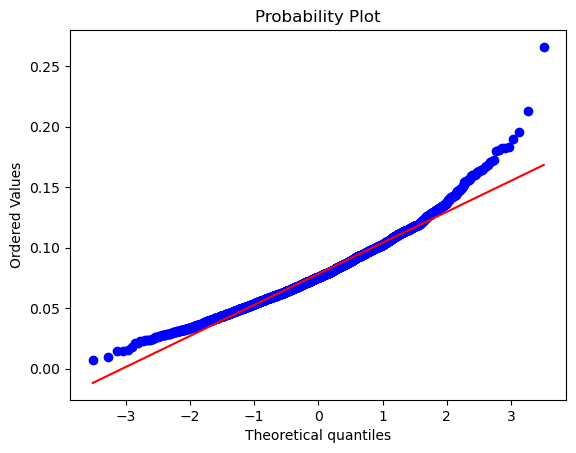

In [14]:
# inspect the second latent feature
feature = df_latent['fp_1']
# histogram
sns.histplot(feature, kde=True, bins=30)
plt.show()
# Q-Q plot
stats.probplot(feature, dist="norm", plot=plt)
plt.show()

In [15]:
print(df_latent['fp_0'].skew(axis=0, skipna=True))
print(df_latent['fp_1'].skew())

0.8097395627918138
0.7682935794188365


In [16]:
def detect_outliers(df, feature):
    zscores = (df[feature] - df[feature].mean())/df[feature].std(ddof=0)

    lower_outliers = df[zscores < -3]
    upper_outliers = df[zscores > 3]

    lower_percent = len(lower_outliers) / len(df) * 100
    upper_percent = len(upper_outliers) / len(df) * 100

    return lower_percent, upper_percent

In [17]:
lower_percent, upper_percent = detect_outliers(df_latent, 'fp_0')
print(lower_percent, upper_percent)
lower_percent, upper_percent = detect_outliers(df_latent, 'fp_1')
print(lower_percent, upper_percent)

0.0 1.0359339592101005
0.0 0.9388151505341535


Add latent fingerprint descriptors in a single column and scale them

In [18]:
df_latent['latent_fp'] = [np.array(df_latent.iloc[x, np.where(['fp_' in col for col in df_latent.columns])[0]]) for x in range(df_latent.shape[0])]
df_latent.head()

,Structure,fp_0,fp_1,fp_2,fp_3,fp_4,fp_5,fp_6,fp_7,fp_8,fp_9,fp_10,fp_11,fp_12,fp_13,fp_14,fp_15,fp_16,fp_17,fp_18,fp_19,fp_20,fp_21,fp_22,fp_23,fp_24,fp_25,fp_26,fp_27,fp_28,fp_29,fp_30,fp_31,fp_32,fp_33,fp_34,fp_35,fp_36,fp_37,fp_38,fp_39,fp_40,fp_41,fp_42,fp_43,fp_44,fp_45,fp_46,fp_47,fp_48,fp_49,fp_50,fp_51,fp_52,fp_53,fp_54,fp_55,fp_56,fp_57,fp_58,fp_59,fp_60,fp_61,fp_62,fp_63,fp_64,fp_65,fp_66,fp_67,fp_68,fp_69,fp_70,fp_71,fp_72,fp_73,fp_74,fp_75,fp_76,fp_77,fp_78,fp_79,fp_80,fp_81,fp_82,fp_83,fp_84,fp_85,fp_86,fp_87,fp_88,fp_89,fp_90,fp_91,fp_92,fp_93,fp_94,fp_95,fp_96,fp_97,fp_98,fp_99,fp_100,fp_101,fp_102,fp_103,fp_104,fp_105,fp_106,fp_107,fp_108,fp_109,fp_110,fp_111,fp_112,fp_113,fp_114,fp_115,fp_116,fp_117,fp_118,fp_119,fp_120,fp_121,fp_122,fp_123,fp_124,fp_125,fp_126,fp_127,fp_128,fp_129,fp_130,fp_131,fp_132,fp_133,fp_134,fp_135,fp_136,fp_137,fp_138,fp_139,fp_140,fp_141,fp_142,fp_143,fp_144,fp_145,fp_146,fp_147,fp_148,fp_149,fp_150,fp_151,fp_152,fp_153,fp_154,fp_155,fp_156,fp_157,fp_158,fp_159,fp_160,fp_161,fp_162,fp_163,fp_164,fp_165,fp_166,fp_167,fp_168,fp_169,fp_170,fp_171,fp_172,fp_173,fp_174,fp_175,fp_176,fp_177,fp_178,fp_179,fp_180,fp_181,fp_182,fp_183,fp_184,fp_185,fp_186,fp_187,fp_188,fp_189,fp_190,fp_191,fp_192,fp_193,fp_194,fp_195,fp_196,fp_197,fp_198,fp_199,fp_200,fp_201,fp_202,fp_203,fp_204,fp_205,fp_206,fp_207,fp_208,fp_209,fp_210,fp_211,fp_212,fp_213,fp_214,fp_215,fp_216,fp_217,fp_218,fp_219,fp_220,fp_221,fp_222,fp_223,fp_224,fp_225,fp_226,fp_227,fp_228,fp_229,fp_230,fp_231,fp_232,fp_233,fp_234,fp_235,fp_236,fp_237,fp_238,fp_239,fp_240,fp_241,fp_242,fp_243,fp_244,fp_245,fp_246,fp_247,fp_248,fp_249,fp_250,fp_251,fp_252,fp_253,fp_254,fp_255,fp_256,fp_257,fp_258,fp_259,fp_260,fp_261,fp_262,fp_263,fp_264,fp_265,fp_266,fp_267,fp_268,fp_269,fp_270,fp_271,fp_272,fp_273,fp_274,fp_275,fp_276,fp_277,fp_278,fp_279,fp_280,fp_281,fp_282,fp_283,fp_284,fp_285,fp_286,fp_287,fp_288,fp_289,fp_290,fp_291,fp_292,fp_293,fp_294,fp_295,fp_296,fp_297,fp_298,fp_299,latent_fp
0,CNc1cc(Nc2cccn(-c3ccccn3)c2=O)nn2c(C(=O)N[C@@H...,0.102347,0.054541,0.032198,0.021910,0.080763,0.054561,0.054558,0.076734,0.021058,0.051388,0.078008,0.016625,0.042656,0.064288,0.080322,0.011311,0.076945,0.048391,0.054067,0.085729,0.046380,0.047139,0.019532,0.019619,0.119058,0.022409,0.085173,0.031565,0.051127,0.051672,0.026186,0.015438,0.005633,0.048692,0.039253,0.060406,0.058025,0.010882,0.068090,0.015860,0.069062,0.000000,0.076146,0.061541,0.028958,0.047042,0.031075,0.010595,0.092155,0.039163,0.058588,0.003852,0.018171,0.038357,0.071770,0.017127,0.079550,0.060592,0.000000,0.000000,0.036933,0.060277,0.049305,0.038145,0.083940,0.0,0.003250,0.0,0.027118,0.056629,0.075868,0.011965,0.041859,0.010377,0.046608,0.042506,0.047884,0.018655,0.106667,0.035859,0.106805,0.025074,0.056745,0.000693,0.003708,0.098430,0.101758,0.0,0.011152,0.090362,0.0,0.062805,0.014348,0.019577,0.049730,0.022948,0.125368,0.101927,0.061917,0.027272,0.082152,0.055059,0.028944,0.046703,0.014997,0.040303,0.014353,0.009739,0.032570,0.025489,0.046694,0.011549,0.041857,0.002865,0.000000,0.026797,0.017145,0.064090,0.0,0.060989,0.094570,0.016325,0.029194,0.022399,0.0,0.067501,0.061959,0.0,0.029182,0.067182,0.008651,0.027078,0.098394,0.016457,0.005934,0.001258,0.030848,0.025616,0.002892,0.071214,0.033300,0.040931,0.023619,0.0,0.004965,0.088929,0.0,0.076484,0.020897,0.081882,0.048407,0.012411,0.089589,0.019037,0.027291,0.053189,0.015330,0.029546,0.072273,0.115715,0.064427,0.071009,0.044495,0.058469,0.0,0.086507,0.007881,0.017760,0.019925,0.052018,0.052330,0.021329,0.019409,0.012720,0.051125,0.042717,0.042608,0.009204,0.076010,0.148097,0.029730,0.053642,0.025328,0.026530,0.059228,0.017588,0.006959,0.029966,0.029815,0.122906,0.071648,0.046879,0.0,0.0,0.066169,0.055076,0.004837,0.039374,0.001438,0.056531,0.0,0.035248,0.0,0.006546,0.023235,0.012112,0.015332,0.013690,0.0,0.029187,0.054121,0.012464,0.008457,0.073394,0.048189,0.099142,0.029388,0.076162,0.072855,0.019686,0.061909,0.012053,0.014900,0.102

Merge latent representations

In [19]:
set(df.Structure) == set(df_latent.Structure)

True

In [20]:
print(df.shape)
print(df_latent.shape)
df = df.merge(df_latent[['Structure','latent_fp']], on=['Structure'])
print(df.shape)
df.head()

(3089, 9)
(3089, 302)
(3089, 10)


,Id,Structure,rLM LogCLint,hLM LogCLint,which_set,predicted rLM LogCLint,predicted hLM LogCLint,variance rLM LogCLint,variance hLM LogCLint,latent_fp
0,Mol1,CNc1cc(Nc2cccn(-c3ccccn3)c2=O)nn2c(C(=O)N[C@@H...,1.392169,0.675687,TRAIN,1.390602,0.826801,0.004089,0.002332,"[0.102347344, 0.05454072, 0.03219829, 0.021910..."
1,Mol6,CC#CC(=O)N[C@H]1CCCN(c2c(F)cc(C(N)=O)c3[nH]c(C...,2.376374,1.397349,TRAIN,2.626149,1.717698,0.002975,0.003191,"[0.06738016, 0.09796607, 0.027471267, 0.065018..."
2,Mol8,COc1ccc(Cl)cc1C(=O)NCCc1ccc(S(=O)(=O)NC(=O)NC2...,2.728062,1.458063,TRAIN,2.490598,1.686410,0.005649,0.004861,"[0.0961938, 0.13077441, 0.056418438, 0.0877562..."
3,Mol9,C=CC(=O)N1CCC[C@@H](n2nc(-c3ccc(Oc4ccccc4)cc3)...,3.243300,2.756500,TRAIN,2.878103,1.868621,0.006237,0.004062,"[0.07866653, 0.10019734, 0.019805629, 0.064256..."
4,Mol10,CC(C)NC(=O)COc1cccc(-c2nc(Nc3ccc4[nH]ncc4c3)c3...,3.192741,1.630824,TRAIN,2.898273,1.916554,0.004985,0.004834,"[0.089213915, 0.10956318, 0.013584262, 0.06330..."


Given that most of latent fingerprint features show a positively skewed distribution (which does not follow a Gaussian distribution) and have a significant percentage of outliers (more than 0.3% as determined from the Z-score detection method), we employed a Robust Scaler to perform feature transformation, rather than using a Standard Scaler.

In [21]:
from sklearn.preprocessing import RobustScaler
scaler = RobustScaler()
scaler.fit(np.array([np.array(x) for x in df[df.which_set == 'TRAIN'].latent_fp]))
df['latent_fp_scaled'] = [list(i) for i in scaler.transform(np.array([np.array(x) for x in df.latent_fp]))]
df = df.drop(columns='latent_fp')
df.head()

,Id,Structure,rLM LogCLint,hLM LogCLint,which_set,predicted rLM LogCLint,predicted hLM LogCLint,variance rLM LogCLint,variance hLM LogCLint,latent_fp_scaled
0,Mol1,CNc1cc(Nc2cccn(-c3ccccn3)c2=O)nn2c(C(=O)N[C@@H...,1.392169,0.675687,TRAIN,1.390602,0.826801,0.004089,0.002332,"[1.9928862435024364, -0.6595477327372177, 1.29..."
1,Mol6,CC#CC(=O)N[C@H]1CCCN(c2c(F)cc(C(N)=O)c3[nH]c(C...,2.376374,1.397349,TRAIN,2.626149,1.717698,0.002975,0.003191,"[0.6471675164597545, 0.6435356452621832, 0.920..."
2,Mol8,COc1ccc(Cl)cc1C(=O)NCCc1ccc(S(=O)(=O)NC(=O)NC2...,2.728062,1.458063,TRAIN,2.490598,1.686410,0.005649,0.004861,"[1.756065932250574, 1.6280297832196866, 3.2077..."
3,Mol9,C=CC(=O)N1CCC[C@@H](n2nc(-c3ccc(Oc4ccccc4)cc3)...,3.243300,2.756500,TRAIN,2.878103,1.868621,0.006237,0.004062,"[1.0815256125916224, 0.7104903352952795, 0.315..."
4,Mol10,CC(C)NC(=O)COc1cccc(-c2nc(Nc3ccc4[nH]ncc4c3)c3...,3.192741,1.630824,TRAIN,2.898273,1.916554,0.004985,0.004834,"[1.4874437304426076, 0.9915351725850632, -0.17..."


## Save final datasets

Save the generated UNIQUE input dataset for each endpoint into a separate CSV file.

In [22]:
for endpoint in ['rLM LogCLint', 'hLM LogCLint']:

    print(f'\n{endpoint}')
    df_endpoint = df[['Id', 'Structure', f'{endpoint}', f'predicted {endpoint}', f'variance {endpoint}', 'which_set', 'latent_fp_scaled']]
    df_endpoint.columns = ['Id', 'Structure', 'labels', 'predictions', 'variance', 'which_set', 'latent_fp_scaled']

    print(df_endpoint.shape)
    df_endpoint = df_endpoint.dropna()
    print(df_endpoint.shape)

    print(df_endpoint.which_set.value_counts())
    print(df_endpoint.which_set.value_counts()/df_endpoint.which_set.value_counts().sum() * 100)

    if not os.path.exists('unique_input_data'):
        os.makedirs('unique_input_data')

    df_endpoint.to_csv(f'unique_input_data/{endpoint}_unique_input_data.csv')


rLM LogCLint
(3089, 7)
(3051, 7)
which_set
TRAIN          1527
CALIBRATION     915
TEST            609
Name: count, dtype: int64
which_set
TRAIN          50.049164
CALIBRATION    29.990167
TEST           19.960669
Name: count, dtype: float64

hLM LogCLint
(3089, 7)
(3084, 7)
which_set
TRAIN          1544
CALIBRATION     924
TEST            616
Name: count, dtype: int64
which_set
TRAIN          50.064851
CALIBRATION    29.961089
TEST           19.974060
Name: count, dtype: float64
